In [13]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
from skimage.util import img_as_ubyte
from skimage.morphology import disk
from skimage import exposure
from skimage.filters import rank

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

synth_ds_fp = [no_aug_synth_ds.samples[i][0] for i in range(len(no_aug_synth_ds))]

mixed_clutter = {file: (os.path.join(clutter_dir, 'HB06158'), 200, 280) for file in synth_ds_fp}

mixed_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(mixed_clutter), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
idx = 0
img = no_aug_synth_ds[idx][0][0]
t, s, c = choi_segmentation(img, high = 95, low = 30)
mask = torch.tensor(t+s, dtype = torch.uint8)
seg_img = img * mask
clutter = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))[200: 200+128, 280:280+128]

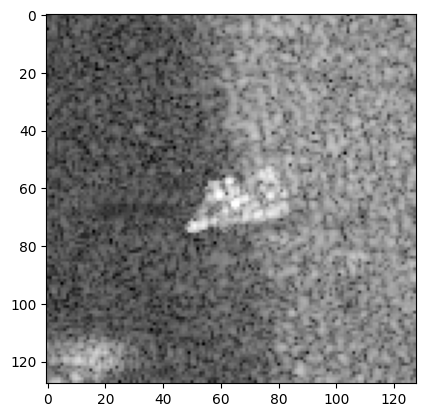

In [19]:
plt.imshow(mixed_synth_ds[idx][0][0], cmap = "gray")

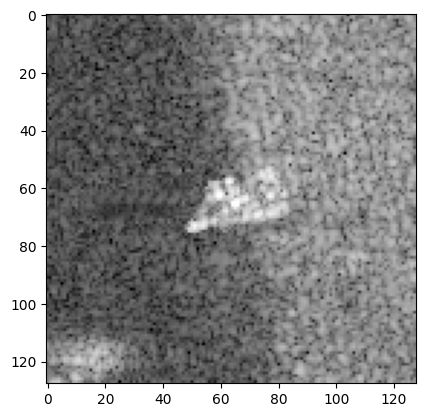

In [16]:
plt.imshow(img_as_ubyte(mixed_synth_ds[idx][0][0]), cmap = "grey")

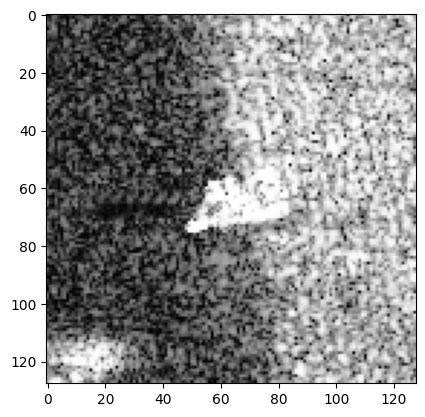

In [17]:
plt.imshow(exposure.equalize_hist(img_as_ubyte(mixed_synth_ds[idx][0][0])), cmap = "grey")

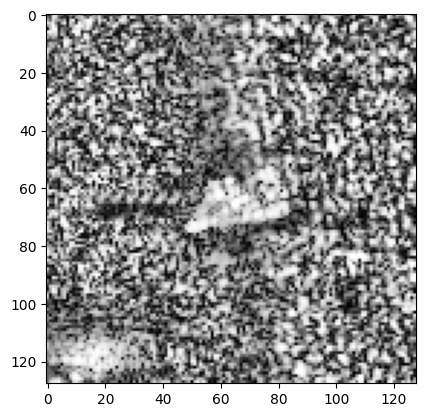

In [18]:
plt.imshow(rank.equalize(img_as_ubyte(mixed_synth_ds[idx][0][0]), footprint = disk(20)), cmap = "gray")

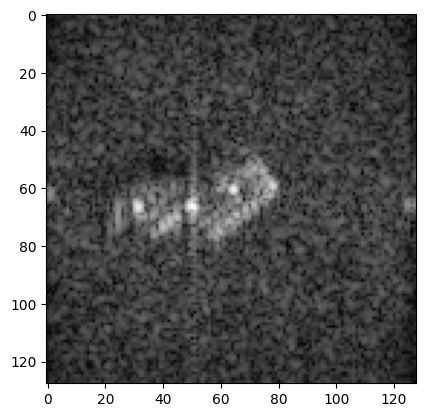

In [31]:
plt.imshow(no_aug_synth_ds[777][0][0], cmap = "gray")

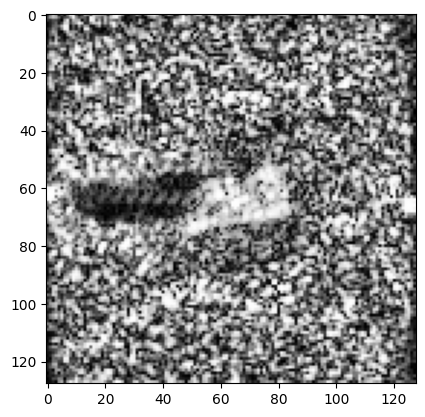

In [22]:
plt.imshow(rank.equalize(img_as_ubyte(no_aug_synth_ds[idx][0][0]), footprint = disk(20)), cmap = "gray")

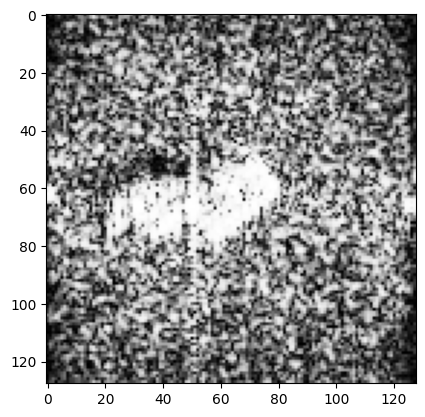

In [30]:
plt.imshow(exposure.equalize_hist(img_as_ubyte(no_aug_synth_ds[777][0][0])), cmap = "grey")

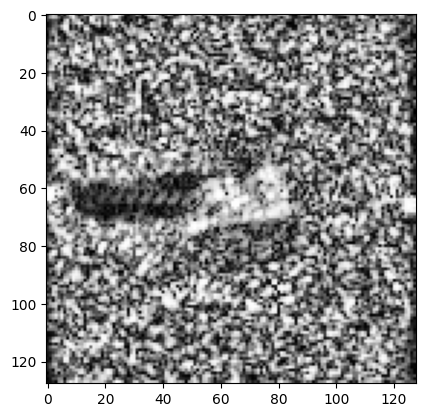

In [27]:
plt.imshow(exposure.equalize_adapthist(img_as_ubyte(no_aug_synth_ds[idx][0][0]), clip_limit=0.03), cmap = "gray")